# Système de Recommandation par Réseaux de Neurones Convolutifs sur Graphes (LightGCN)

## Filtrage collaboratif sur le jeu de données MovieLens (ml-latest-small)

Ce notebook implémente, entraîne et évalue un système de recommandation basé sur **LightGCN**
(*Light Graph Convolutional Network*), une simplification efficace des réseaux de neurones
convolutifs pour graphes (GCN) appliquée au filtrage collaboratif.

### Objectifs du projet

1. Représenter les interactions utilisateur-article sous la forme d'un **graphe biparti**.
2. Implémenter **LightGCN** en PyTorch avec propagation d'embeddings multicouches (*message passing*).
3. Entraîner le modèle avec la fonction de perte **BPR** (*Bayesian Personalized Ranking*).
4. Évaluer les performances avec les métriques **Recall@K** et **NDCG@K**.
5. Générer des recommandations **Top-K** personnalisées.
6. Analyser le comportement des embeddings appris.
7. Exporter les artefacts nécessaires au déploiement (backend Flask).

### Plan du notebook

1. Importation des bibliothèques et configuration
2. Chargement des données MovieLens
3. Analyse exploratoire des données (EDA)
4. Prétraitement et découpage train/validation/test
5. Construction du graphe biparti utilisateur-article
6. Implémentation du modèle LightGCN
7. Fonction de perte BPR et échantillonnage négatif
8. Métriques d'évaluation (Recall@K, NDCG@K)
9. Recherche des meilleurs hyperparamètres
10. Entraînement du modèle final
11. Évaluation finale et comparaison avec une baseline
12. Analyse des embeddings appris
13. Génération de recommandations Top-K
14. Export des artefacts pour le déploiement


## 1. Importation des bibliothèques et configuration

In [1]:
# Bibliothèques standards et scientifiques
import os
import json
import random
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch pour l'implémentation de LightGCN
import torch
import torch.nn as nn

# Réduction de dimension pour l'analyse des embeddings
from sklearn.decomposition import PCA

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

# Graine aléatoire pour la reproductibilité des résultats
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Périphérique de calcul (CPU suffisant pour ce jeu de données)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Périphérique utilisé : {DEVICE}")

# Chemins
DATA_DIR = os.path.join("data", "ml-latest-small")
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)


Périphérique utilisé : cpu


## 2. Chargement des données MovieLens

Le jeu de données utilisé est **MovieLens ml-latest-small**, recommandé par la consigne du
projet. Il contient :

- `ratings.csv` : les interactions (notes) entre utilisateurs et films,
- `movies.csv` : les métadonnées des films (titre, genres),
- `links.csv` : les identifiants externes (IMDb, TMDb) permettant de récupérer les affiches,
- `tags.csv` : les tags textuels apposés par les utilisateurs sur les films.


In [2]:
ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
movies = pd.read_csv(os.path.join(DATA_DIR, "movies.csv"))
links = pd.read_csv(os.path.join(DATA_DIR, "links.csv"))
tags = pd.read_csv(os.path.join(DATA_DIR, "tags.csv"))

print("Aperçu des notes (ratings.csv) :")
display(ratings.head())
print("\nAperçu des films (movies.csv) :")
display(movies.head())
print("\nAperçu des liens externes (links.csv) :")
display(links.head())


Aperçu des notes (ratings.csv) :


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Aperçu des films (movies.csv) :


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Aperçu des liens externes (links.csv) :


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [3]:
print(f"Nombre total de notes (interactions)  : {len(ratings):,}")
print(f"Nombre d'utilisateurs uniques            : {ratings['userId'].nunique():,}")
print(f"Nombre de films uniques notés            : {ratings['movieId'].nunique():,}")
print(f"Nombre de films dans movies.csv          : {movies['movieId'].nunique():,}")
print(f"Période couverte                         : "
      f"{pd.to_datetime(ratings['timestamp'], unit='s').min().date()} -> "
      f"{pd.to_datetime(ratings['timestamp'], unit='s').max().date()}")

n_users_raw = ratings['userId'].nunique()
n_items_raw = ratings['movieId'].nunique()
sparsity = 1 - len(ratings) / (n_users_raw * n_items_raw)
print(f"Sparsité de la matrice utilisateur-item  : {sparsity:.4%}")


Nombre total de notes (interactions)  : 100,836
Nombre d'utilisateurs uniques            : 610
Nombre de films uniques notés            : 9,724
Nombre de films dans movies.csv          : 9,742
Période couverte                         : 1996-03-29 -> 2018-09-24
Sparsité de la matrice utilisateur-item  : 98.3000%


## 3. Analyse exploratoire des données (EDA)

Cette section explore la distribution des notes, l'activité des utilisateurs, la popularité
des films et les genres présents dans le catalogue, afin de mieux comprendre les
caractéristiques du graphe d'interaction que nous allons construire.

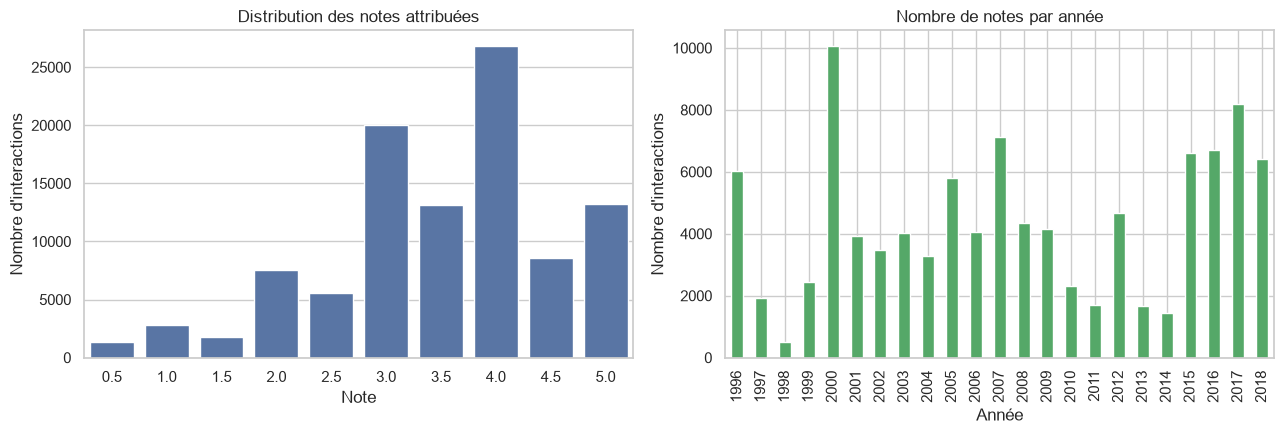

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution des notes attribuées
sns.countplot(x="rating", data=ratings, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution des notes attribuées")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre d'interactions")

# Nombre de notes par mois (évolution temporelle)
ratings_dt = pd.to_datetime(ratings['timestamp'], unit='s')
ratings_dt.dt.to_period("Y").value_counts().sort_index().plot(kind="bar", color="#55A868", ax=axes[1])
axes[1].set_title("Nombre de notes par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre d'interactions")

plt.tight_layout()
plt.show()


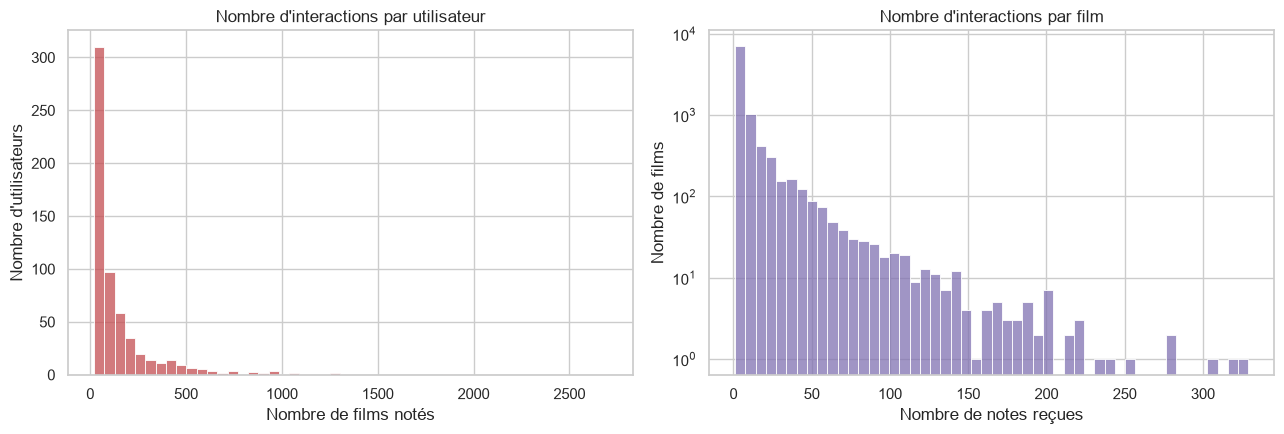

Interactions par utilisateur : min=20, médiane=70, max=2698
Interactions par film        : min=1, médiane=3, max=329


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

interactions_per_user = ratings.groupby("userId").size()
interactions_per_item = ratings.groupby("movieId").size()

sns.histplot(interactions_per_user, bins=50, color="#C44E52", ax=axes[0])
axes[0].set_title("Nombre d'interactions par utilisateur")
axes[0].set_xlabel("Nombre de films notés")
axes[0].set_ylabel("Nombre d'utilisateurs")

sns.histplot(interactions_per_item, bins=50, color="#8172B2", ax=axes[1])
axes[1].set_title("Nombre d'interactions par film")
axes[1].set_xlabel("Nombre de notes reçues")
axes[1].set_ylabel("Nombre de films")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Interactions par utilisateur : min={interactions_per_user.min()}, "
      f"médiane={interactions_per_user.median():.0f}, max={interactions_per_user.max()}")
print(f"Interactions par film        : min={interactions_per_item.min()}, "
      f"médiane={interactions_per_item.median():.0f}, max={interactions_per_item.max()}")


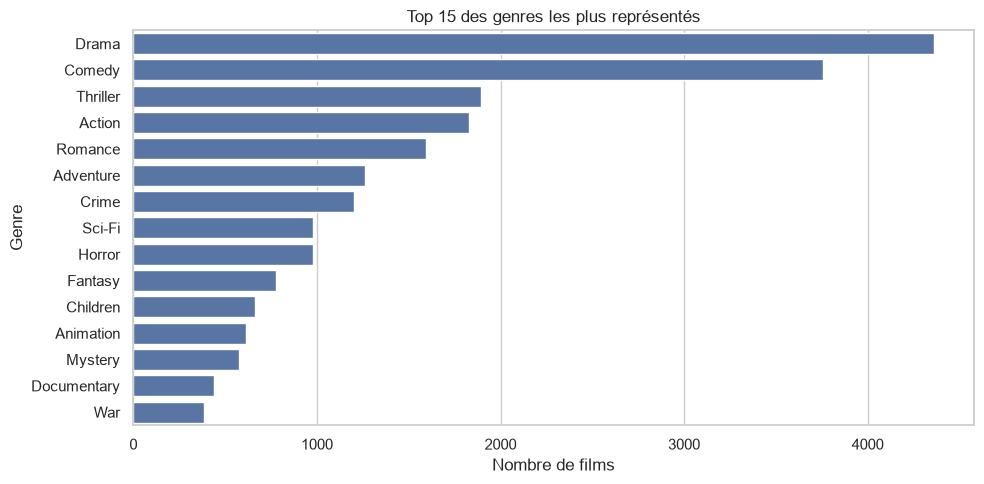

In [6]:
# Genres les plus représentés dans le catalogue
genres_series = movies['genres'].str.split("|").explode()
genres_count = genres_series.value_counts().drop(labels=["(no genres listed)"], errors="ignore")

plt.figure(figsize=(10, 5))
sns.barplot(x=genres_count.values[:15], y=genres_count.index[:15], color="#4C72B0")
plt.title("Top 15 des genres les plus représentés")
plt.xlabel("Nombre de films")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


In [7]:
# Films les plus populaires (nombre de notes)
top_movies = (
    ratings.groupby("movieId").size().rename("nb_notes")
    .to_frame().join(movies.set_index("movieId")["title"])
    .sort_values("nb_notes", ascending=False).head(10)
)
print("Top 10 des films les plus notés :")
display(top_movies[["title", "nb_notes"]])


Top 10 des films les plus notés :


,title,nb_notes
movieId,,
356,Forrest Gump (1994),329
318,"Shawshank Redemption, The (1994)",317
296,Pulp Fiction (1994),307
593,"Silence of the Lambs, The (1991)",279
2571,"Matrix, The (1999)",278
260,Star Wars: Episode IV - A New Hope (1977),251
480,Jurassic Park (1993),238
110,Braveheart (1995),237
589,Terminator 2: Judgment Day (1991),224


## 4. Prétraitement des données

### 4.1 Construction des interactions implicites

Conformément à la consigne, nous représentons les interactions utilisateur-article sous forme
d'un **graphe biparti de filtrage collaboratif** : chaque note attribuée par un utilisateur à un
film, quelle que soit sa valeur, est considérée comme un signal d'interaction implicite
(*l'utilisateur a vu et évalué ce film*). C'est l'approche standard pour entraîner LightGCN avec
la perte BPR.

### 4.2 Ré-indexation

Les identifiants `userId` et `movieId` originaux ne sont pas contigus. Nous les ré-indexons en
indices entiers `0..n_users-1` et `0..n_items-1`, nécessaires pour les tables d'embeddings et la
matrice d'adjacence.

### 4.3 Découpage train / validation / test

Pour chaque utilisateur, nous répartissons aléatoirement ses interactions en :
- **70 %** pour l'entraînement (construction du graphe + perte BPR),
- **10 %** pour la validation (sélection des hyperparamètres, arrêt anticipé),
- **20 %** pour le test (évaluation finale Recall@K / NDCG@K).

Ce découpage *par utilisateur* garantit que chaque utilisateur est représenté dans les trois
ensembles, ce qui est indispensable pour l'évaluation du Top-K.

In [8]:
# Ré-indexation des utilisateurs et des films en indices contigus 0..N-1
unique_users = np.sort(ratings['userId'].unique())
unique_items = np.sort(ratings['movieId'].unique())

user2idx = {int(u): i for i, u in enumerate(unique_users)}
item2idx = {int(m): i for i, m in enumerate(unique_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: m for m, i in item2idx.items()}

ratings['u'] = ratings['userId'].map(user2idx)
ratings['i'] = ratings['movieId'].map(item2idx)

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)
print(f"Nombre d'utilisateurs (ré-indexés) : {N_USERS}")
print(f"Nombre de films (ré-indexés)       : {N_ITEMS}")


Nombre d'utilisateurs (ré-indexés) : 610
Nombre de films (ré-indexés)       : 9724


In [9]:
def split_train_val_test(df, seed=SEED, val_ratio=0.1, test_ratio=0.2):
    '''Découpe les interactions de chaque utilisateur en train/val/test.'''
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []
    for _, group in df.groupby('u'):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_test = max(1, int(round(n * test_ratio)))
        n_val = max(1, int(round(n * val_ratio)))
        # S'assurer qu'il reste au moins une interaction pour l'entraînement
        n_test = min(n_test, n - 2) if n > 2 else 0
        n_val = min(n_val, n - n_test - 1) if (n - n_test) > 1 else 0
        test_idx.extend(idx[:n_test])
        val_idx.extend(idx[n_test:n_test + n_val])
        train_idx.extend(idx[n_test + n_val:])
    return df.loc[train_idx].reset_index(drop=True), \
           df.loc[val_idx].reset_index(drop=True), \
           df.loc[test_idx].reset_index(drop=True)

train_df, val_df, test_df = split_train_val_test(ratings)
print(f"Interactions d'entraînement : {len(train_df):,} ({len(train_df)/len(ratings):.1%})")
print(f"Interactions de validation  : {len(val_df):,} ({len(val_df)/len(ratings):.1%})")
print(f"Interactions de test        : {len(test_df):,} ({len(test_df)/len(ratings):.1%})")


Interactions d'entraînement : 70,579 (70.0%)
Interactions de validation  : 10,093 (10.0%)
Interactions de test        : 20,164 (20.0%)


## 5. Construction du graphe biparti utilisateur-article

LightGCN modélise les interactions utilisateur-article comme un **graphe biparti non orienté** :
- les utilisateurs $u \in \{0, ..., n_{users}-1\}$ et les articles $i \in \{0, ..., n_{items}-1\}$
  sont les nœuds du graphe,
- une arête relie $u$ et $i$ si l'utilisateur $u$ a interagi avec l'article $i$ dans l'ensemble
  d'entraînement.

La matrice d'adjacence du graphe complet (utilisateurs + articles) s'écrit par blocs :

$$A = \begin{pmatrix} 0 & R \\ R^\top & 0 \end{pmatrix}$$

où $R$ est la matrice d'interaction utilisateur-article ($n_{users} \times n_{items}$).

Pour stabiliser la propagation des messages, LightGCN utilise la matrice d'adjacence
**normalisée symétriquement** :

$$\tilde{A} = D^{-1/2} A D^{-1/2}$$

où $D$ est la matrice diagonale des degrés de $A$. Cette normalisation est convertie en tenseur
creux PyTorch pour permettre une propagation efficace par multiplication matricielle creuse.

In [10]:
def build_normalized_adj(train_df, n_users, n_items):
    '''Construit la matrice d'adjacence normalisée symétriquement (D^-1/2 A D^-1/2).'''
    u = train_df['u'].to_numpy()
    i = train_df['i'].to_numpy()

    # Matrice d'interaction utilisateur-article R (n_users x n_items)
    R = sp.csr_matrix((np.ones(len(u), dtype=np.float32), (u, i)), shape=(n_users, n_items))

    # Matrice d'adjacence complète par blocs : [[0, R], [R^T, 0]]
    n_nodes = n_users + n_items
    adj = sp.bmat([[None, R], [R.T, None]], format="csr")

    # Normalisation symétrique D^-1/2 A D^-1/2
    degree = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.zeros_like(degree)
    nonzero = degree > 0
    d_inv_sqrt[nonzero] = np.power(degree[nonzero], -0.5)
    D_inv_sqrt = sp.diags(d_inv_sqrt)

    norm_adj = (D_inv_sqrt @ adj @ D_inv_sqrt).tocoo()
    return norm_adj, R

norm_adj, R_train = build_normalized_adj(train_df, N_USERS, N_ITEMS)

# Conversion en tenseur creux PyTorch (format COO)
indices = torch.LongTensor(np.vstack((norm_adj.row, norm_adj.col)))
values = torch.FloatTensor(norm_adj.data)
SPARSE_ADJ = torch.sparse_coo_tensor(
    indices, values, torch.Size((N_USERS + N_ITEMS, N_USERS + N_ITEMS))
).coalesce().to(DEVICE)

print(f"Graphe biparti : {N_USERS + N_ITEMS} nœuds, {norm_adj.nnz:,} arêtes (avec symétrie)")


Graphe biparti : 10334 nœuds, 141,158 arêtes (avec symétrie)


C:\Users\DIFFO GARNEL\AppData\Local\Temp\ipykernel_18504\4268937629.py:28: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  SPARSE_ADJ = torch.sparse_coo_tensor(


## 6. Implémentation du modèle LightGCN

LightGCN simplifie les GCN traditionnels en supprimant les transformations linéaires et les
fonctions d'activation non linéaires des couches de convolution, conservant uniquement
l'opération essentielle : **l'agrégation pondérée des voisins** (*propagation de messages*).

### Propagation des embeddings

À partir des embeddings initiaux $E^{(0)}$ (table d'embeddings apprenable, une ligne par
utilisateur et par article), chaque couche $k$ calcule :

$$E^{(k+1)} = \tilde{A} \, E^{(k)}$$

### Combinaison des couches

L'embedding final de chaque nœud est la **moyenne** de ses représentations à toutes les couches
(y compris la couche d'entrée $E^{(0)}$), ce qui capture des signaux collaboratifs allant du
voisinage direct (1 saut) aux voisinages plus lointains (K sauts) :

$$E_{final} = \frac{1}{K+1}\sum_{k=0}^{K} E^{(k)}$$

### Score de prédiction

Le score de préférence prédit entre un utilisateur $u$ et un article $i$ est le **produit
scalaire** de leurs embeddings finaux :

$$\hat{y}_{ui} = e_u^\top e_i$$

In [11]:
class LightGCN(nn.Module):
    '''Implémentation de LightGCN : propagation d'embeddings sur un graphe biparti.'''

    def __init__(self, n_users, n_items, embedding_dim, n_layers, sparse_adj):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.sparse_adj = sparse_adj

        # Table d'embeddings unique pour les utilisateurs (lignes 0..n_users-1)
        # et les articles (lignes n_users..n_users+n_items-1)
        self.embedding = nn.Embedding(n_users + n_items, embedding_dim)
        nn.init.normal_(self.embedding.weight, std=0.1)

    def propagate(self):
        '''Propage les embeddings à travers les couches de convolution sur graphe.'''
        all_emb = self.embedding.weight
        embeddings_per_layer = [all_emb]

        current = all_emb
        for _ in range(self.n_layers):
            current = torch.sparse.mm(self.sparse_adj, current)
            embeddings_per_layer.append(current)

        # Combinaison des couches par moyenne (lissage du signal collaboratif)
        stacked = torch.stack(embeddings_per_layer, dim=1)
        final_embeddings = stacked.mean(dim=1)

        users_emb, items_emb = torch.split(final_embeddings, [self.n_users, self.n_items])
        return users_emb, items_emb

    def forward(self):
        return self.propagate()

    def get_ego_embeddings(self, users, pos_items, neg_items):
        '''Renvoie les embeddings de la couche 0 (utilisés pour la régularisation L2).'''
        u_emb0 = self.embedding.weight[users]
        pos_emb0 = self.embedding.weight[self.n_users + pos_items]
        neg_emb0 = self.embedding.weight[self.n_users + neg_items]
        return u_emb0, pos_emb0, neg_emb0


## 7. Fonction de perte BPR et échantillonnage négatif

LightGCN est entraîné avec la perte **BPR (Bayesian Personalized Ranking)**, conçue pour les
retours implicites. Pour chaque triplet $(u, i^+, i^-)$ - un utilisateur $u$, un article
**positif** $i^+$ avec lequel il a réellement interagi, et un article **négatif** $i^-$
échantillonné aléatoirement parmi les articles non vus -, la perte encourage le score
$\hat{y}_{ui^+}$ à être supérieur au score $\hat{y}_{ui^-}$ :

$$\mathcal{L}_{BPR} = -\sum_{(u,i^+,i^-)} \log \sigma(\hat{y}_{ui^+} - \hat{y}_{ui^-}) +
\lambda \, \lVert E^{(0)} \rVert_2^2$$

Le terme de régularisation $L_2$ ne porte que sur les embeddings de la **couche 0** (les seuls
paramètres appris directement), comme préconisé dans l'article original de LightGCN.

In [12]:
# Pré-calcul, pour chaque utilisateur, de la liste des articles positifs (entraînement)
user_pos_items = train_df.groupby('u')['i'].apply(lambda s: np.array(sorted(set(s)))).to_dict()
user_pos_set = {u: set(arr.tolist()) for u, arr in user_pos_items.items()}


def sample_bpr_batch(batch_size, n_users, n_items, user_pos_items, user_pos_set):
    '''Échantillonne un batch de triplets (utilisateur, article positif, article négatif).'''
    users = np.random.randint(0, n_users, size=batch_size)
    pos_items = np.empty(batch_size, dtype=np.int64)
    neg_items = np.random.randint(0, n_items, size=batch_size)

    for k, u in enumerate(users):
        pos_arr = user_pos_items[u]
        pos_items[k] = pos_arr[np.random.randint(len(pos_arr))]
        pos_set = user_pos_set[u]
        while neg_items[k] in pos_set:
            neg_items[k] = np.random.randint(0, n_items)

    return (torch.from_numpy(users).long(),
            torch.from_numpy(pos_items).long(),
            torch.from_numpy(neg_items).long())


def bpr_loss(model, users, pos_items, neg_items, l2_reg):
    '''Calcule la perte BPR et le terme de régularisation L2 sur les ego-embeddings.'''
    users_emb, items_emb = model.propagate()

    u_e = users_emb[users]
    pos_e = items_emb[pos_items]
    neg_e = items_emb[neg_items]

    pos_scores = (u_e * pos_e).sum(dim=-1)
    neg_scores = (u_e * neg_e).sum(dim=-1)

    bpr = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()

    u_e0, pos_e0, neg_e0 = model.get_ego_embeddings(users, pos_items, neg_items)
    reg = (u_e0.norm(2).pow(2) + pos_e0.norm(2).pow(2) + neg_e0.norm(2).pow(2)) / (2 * len(users))

    return bpr + l2_reg * reg, bpr.item()


## 8. Métriques d'évaluation : Recall@K et NDCG@K

L'évaluation est réalisée selon le protocole de **classement intégral** (*all-ranking*) : pour
chaque utilisateur de l'ensemble évalué, le modèle attribue un score à **tous les articles**, les
articles déjà vus pendant l'entraînement (et la validation, le cas échéant) sont exclus du
classement, puis les **K articles avec le score le plus élevé** sont comparés aux articles
réellement présents dans l'ensemble d'évaluation de l'utilisateur.

- **Recall@K** : proportion des articles pertinents (de l'ensemble d'évaluation) retrouvés dans
  le Top-K recommandé.
- **NDCG@K** (*Normalized Discounted Cumulative Gain*) : mesure la qualité du **classement**, en
  donnant plus de poids aux articles pertinents situés en haut de la liste.

In [13]:
def recall_ndcg_at_k(topk_items, ground_truth_items, k):
    '''Calcule Recall@K et NDCG@K pour une liste d'utilisateurs.

    topk_items        : tableau (n_users, k) des indices d'articles recommandés
    ground_truth_items: liste de sets, articles pertinents par utilisateur
    '''
    recalls, ndcgs = [], []
    for row, gt in zip(topk_items, ground_truth_items):
        if len(gt) == 0:
            continue
        hits = np.isin(row[:k], list(gt)).astype(np.float32)

        # Recall@K
        recalls.append(hits.sum() / len(gt))

        # NDCG@K
        discounts = 1.0 / np.log2(np.arange(2, k + 2))
        dcg = (hits * discounts).sum()
        ideal_hits = np.zeros(k, dtype=np.float32)
        ideal_hits[:min(len(gt), k)] = 1.0
        idcg = (ideal_hits * discounts).sum()
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return float(np.mean(recalls)), float(np.mean(ndcgs))


@torch.no_grad()
def evaluate(model, eval_df, mask_dfs, k_list=(10, 20)):
    '''Évalue le modèle sur eval_df (val ou test), en masquant les interactions de mask_dfs.

    mask_dfs : liste de DataFrames dont les interactions (u, i) doivent être exclues
               du classement (ex : train (+ val) pour ne pas les recommander à nouveau).
    '''
    model.eval()
    users_emb, items_emb = model.propagate()
    scores = users_emb @ items_emb.T  # (n_users, n_items)

    # Masquage des interactions déjà connues (score -> -inf pour ne jamais être recommandées)
    for df in mask_dfs:
        scores[df['u'].to_numpy(), df['i'].to_numpy()] = -np.inf

    ground_truth = eval_df.groupby('u')['i'].apply(set).to_dict()
    ground_truth_full = [ground_truth.get(u, set()) for u in range(model.n_users)]

    max_k = max(k_list)
    _, topk_indices = torch.topk(scores, k=max_k, dim=1)
    topk_indices = topk_indices.cpu().numpy()

    results = {}
    for k in k_list:
        recall, ndcg = recall_ndcg_at_k(topk_indices, ground_truth_full, k)
        results[f"recall@{k}"] = recall
        results[f"ndcg@{k}"] = ndcg

    model.train()
    return results


## 9. Recherche des meilleurs hyperparamètres

Nous comparons plusieurs configurations de LightGCN en faisant varier :
- la **dimension des embeddings** (`embedding_dim`) : 32 ou 64,
- le **nombre de couches de propagation** (`n_layers`) : 2 ou 3,

avec un taux d'apprentissage fixe (`1e-3`, Adam) et une régularisation L2 fixe (`1e-4`).

Chaque configuration est entraînée sur un nombre réduit d'épochs (15) afin de comparer
rapidement leur potentiel via le **Recall@20** sur l'ensemble de validation. La meilleure
configuration sera ensuite entraînée plus longuement (section 10).

In [14]:
def train_one_config(embedding_dim, n_layers, lr, l2_reg, n_epochs, batch_size=4096,
                      eval_every=5, k_list=(10, 20), verbose=True):
    '''Entraîne une instance de LightGCN avec la configuration donnée.'''
    model = LightGCN(N_USERS, N_ITEMS, embedding_dim, n_layers, SPARSE_ADJ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_train = len(train_df)
    n_batches = max(1, n_train // batch_size)

    history = {"epoch": [], "loss": [], "val_recall@20": [], "val_ndcg@20": []}

    for epoch in range(1, n_epochs + 1):
        total_loss = 0.0
        for _ in range(n_batches):
            users, pos_items, neg_items = sample_bpr_batch(
                batch_size, N_USERS, N_ITEMS, user_pos_items, user_pos_set)
            users, pos_items, neg_items = users.to(DEVICE), pos_items.to(DEVICE), neg_items.to(DEVICE)

            loss, bpr_value = bpr_loss(model, users, pos_items, neg_items, l2_reg)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += bpr_value

        avg_loss = total_loss / n_batches

        if epoch % eval_every == 0 or epoch == n_epochs:
            val_metrics = evaluate(model, val_df, [train_df], k_list=k_list)
            history["epoch"].append(epoch)
            history["loss"].append(avg_loss)
            history["val_recall@20"].append(val_metrics["recall@20"])
            history["val_ndcg@20"].append(val_metrics["ndcg@20"])
            if verbose:
                print(f"  epoch {epoch:3d} | loss={avg_loss:.4f} | "
                      f"val_recall@20={val_metrics['recall@20']:.4f} | "
                      f"val_ndcg@20={val_metrics['ndcg@20']:.4f}")

    return model, history


In [15]:
# Grille d'hyperparamètres à comparer
GRID = [
    {"embedding_dim": 32, "n_layers": 2},
    {"embedding_dim": 32, "n_layers": 3},
    {"embedding_dim": 64, "n_layers": 2},
    {"embedding_dim": 64, "n_layers": 3},
]
FIXED_LR = 1e-3
FIXED_L2 = 1e-4
SEARCH_EPOCHS = 8

grid_results = []
t0 = time.time()
for cfg in GRID:
    print(f"Configuration : dim={cfg['embedding_dim']}, n_layers={cfg['n_layers']}")
    torch.manual_seed(SEED)
    _, history = train_one_config(
        embedding_dim=cfg["embedding_dim"], n_layers=cfg["n_layers"],
        lr=FIXED_LR, l2_reg=FIXED_L2, n_epochs=SEARCH_EPOCHS,
        eval_every=SEARCH_EPOCHS, verbose=False,
    )
    recall20 = history["val_recall@20"][-1]
    ndcg20 = history["val_ndcg@20"][-1]
    grid_results.append({**cfg, "val_recall@20": recall20, "val_ndcg@20": ndcg20})
    print(f"  -> val_recall@20={recall20:.4f} | val_ndcg@20={ndcg20:.4f}")

print(f"\nRecherche terminée en {time.time()-t0:.1f}s")
grid_df = pd.DataFrame(grid_results).sort_values("val_recall@20", ascending=False)
display(grid_df)


Configuration : dim=32, n_layers=2


C:\Users\DIFFO GARNEL\AppData\Local\Temp\ipykernel_18504\2506224978.py:40: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  scores[df['u'].to_numpy(), df['i'].to_numpy()] = -np.inf


  -> val_recall@20=0.1366 | val_ndcg@20=0.1240
Configuration : dim=32, n_layers=3


  -> val_recall@20=0.1269 | val_ndcg@20=0.1170
Configuration : dim=64, n_layers=2


  -> val_recall@20=0.1426 | val_ndcg@20=0.1220
Configuration : dim=64, n_layers=3


  -> val_recall@20=0.1197 | val_ndcg@20=0.1105

Recherche terminée en 263.2s


,embedding_dim,n_layers,val_recall@20,val_ndcg@20
2,64,2,0.142575,0.121969
0,32,2,0.136552,0.124001
1,32,3,0.126947,0.116963
3,64,3,0.119704,0.110512


In [16]:
best_cfg = grid_df.iloc[0]
BEST_EMBEDDING_DIM = int(best_cfg["embedding_dim"])
BEST_N_LAYERS = int(best_cfg["n_layers"])
print(f"Meilleure configuration retenue : embedding_dim={BEST_EMBEDDING_DIM}, "
      f"n_layers={BEST_N_LAYERS} (val_recall@20={best_cfg['val_recall@20']:.4f})")


Meilleure configuration retenue : embedding_dim=64, n_layers=2 (val_recall@20=0.1426)


## 10. Entraînement du modèle final

Le modèle final est entraîné avec la meilleure configuration trouvée précédemment, sur un plus
grand nombre d'épochs, avec un **arrêt anticipé (early stopping)** basé sur le `Recall@20` de
validation : l'entraînement s'arrête si aucune amélioration n'est observée pendant
`PATIENCE` évaluations consécutives, et les meilleurs poids sont restaurés.

In [17]:
MAX_EPOCHS = 60
EVAL_EVERY = 5
PATIENCE = 5  # nombre d'évaluations sans amélioration avant arrêt anticipé

torch.manual_seed(SEED)
final_model = LightGCN(N_USERS, N_ITEMS, BEST_EMBEDDING_DIM, BEST_N_LAYERS, SPARSE_ADJ).to(DEVICE)
optimizer = torch.optim.Adam(final_model.parameters(), lr=FIXED_LR)

n_batches = max(1, len(train_df) // 4096)
history = {"epoch": [], "loss": [], "val_recall@20": [], "val_ndcg@20": []}
best_recall = -1.0
best_state = None
no_improve = 0

t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    total_loss = 0.0
    for _ in range(n_batches):
        users, pos_items, neg_items = sample_bpr_batch(
            4096, N_USERS, N_ITEMS, user_pos_items, user_pos_set)
        users, pos_items, neg_items = users.to(DEVICE), pos_items.to(DEVICE), neg_items.to(DEVICE)

        loss, bpr_value = bpr_loss(final_model, users, pos_items, neg_items, FIXED_L2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += bpr_value

    avg_loss = total_loss / n_batches

    if epoch % EVAL_EVERY == 0:
        val_metrics = evaluate(final_model, val_df, [train_df], k_list=(10, 20))
        history["epoch"].append(epoch)
        history["loss"].append(avg_loss)
        history["val_recall@20"].append(val_metrics["recall@20"])
        history["val_ndcg@20"].append(val_metrics["ndcg@20"])
        print(f"epoch {epoch:3d} | loss={avg_loss:.4f} | "
              f"val_recall@20={val_metrics['recall@20']:.4f} | "
              f"val_ndcg@20={val_metrics['ndcg@20']:.4f}")

        if val_metrics["recall@20"] > best_recall:
            best_recall = val_metrics["recall@20"]
            best_state = {k: v.clone() for k, v in final_model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"Arrêt anticipé à l'epoch {epoch} (pas d'amélioration depuis "
                      f"{PATIENCE * EVAL_EVERY} epochs).")
                break

print(f"\nEntraînement terminé en {time.time()-t0:.1f}s")

# Restauration des meilleurs poids (meilleur Recall@20 de validation)
final_model.load_state_dict(best_state)
print(f"Meilleur val_recall@20 = {best_recall:.4f}")


epoch   5 | loss=0.6217 | val_recall@20=0.1447 | val_ndcg@20=0.1238


epoch  10 | loss=0.3286 | val_recall@20=0.1398 | val_ndcg@20=0.1207


epoch  15 | loss=0.2244 | val_recall@20=0.1395 | val_ndcg@20=0.1229


epoch  20 | loss=0.1914 | val_recall@20=0.1485 | val_ndcg@20=0.1290


epoch  25 | loss=0.1734 | val_recall@20=0.1580 | val_ndcg@20=0.1360


...

epoch  40 | loss=0.1384 | val_recall@20=0.1651 | val_ndcg@20=0.1417


epoch  45 | loss=0.1319 | val_recall@20=0.1629 | val_ndcg@20=0.1416


epoch  50 | loss=0.1270 | val_recall@20=0.1648 | val_ndcg@20=0.1421


epoch  55 | loss=0.1204 | val_recall@20=0.1681 | val_ndcg@20=0.1435


epoch  60 | loss=0.1166 | val_recall@20=0.1679 | val_ndcg@20=0.1439

Entraînement terminé en 941.9s
Meilleur val_recall@20 = 0.1681


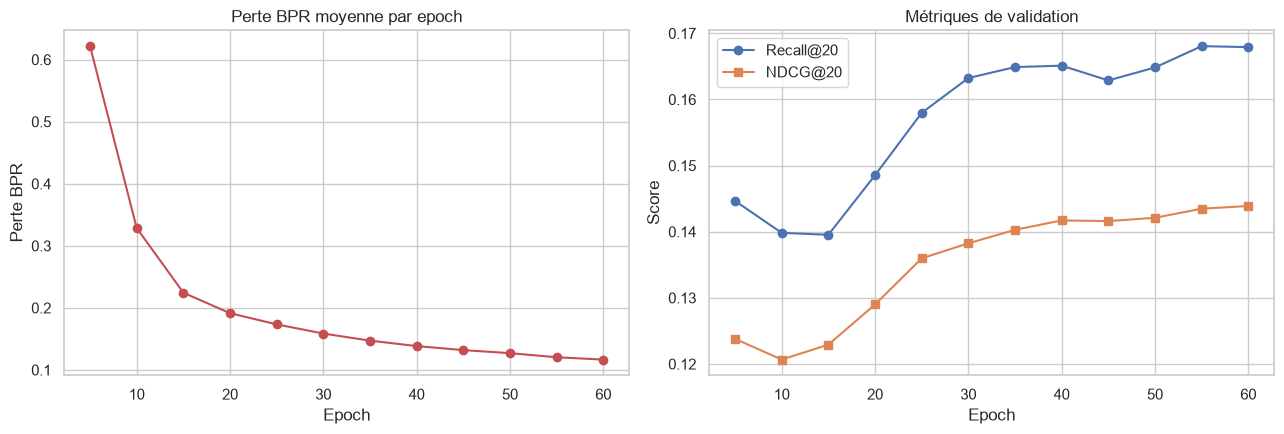

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history["epoch"], history["loss"], marker="o", color="#C44E52")
axes[0].set_title("Perte BPR moyenne par epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Perte BPR")

axes[1].plot(history["epoch"], history["val_recall@20"], marker="o", label="Recall@20")
axes[1].plot(history["epoch"], history["val_ndcg@20"], marker="s", label="NDCG@20")
axes[1].set_title("Métriques de validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Évaluation finale et comparaison avec une baseline

Le modèle final est évalué sur l'**ensemble de test**, jamais utilisé pendant l'entraînement ni
la sélection d'hyperparamètres. Les interactions de `train` **et** de `val` sont masquées lors
du classement (l'utilisateur ne doit pas se voir recommander un film qu'il a déjà noté).

Nous comparons LightGCN à une **baseline de popularité** (recommander systématiquement les
articles les plus populaires de l'ensemble d'entraînement à tous les utilisateurs), afin de
démontrer l'apport du filtrage collaboratif appris par le graphe.

In [19]:
test_metrics = evaluate(final_model, test_df, [train_df, val_df], k_list=(10, 20))
print("Performances de LightGCN sur l'ensemble de test :")
for name, value in test_metrics.items():
    print(f"  {name:>10} = {value:.4f}")


Performances de LightGCN sur l'ensemble de test :
   recall@10 = 0.1089
     ndcg@10 = 0.2306
   recall@20 = 0.1703
     ndcg@20 = 0.2291


In [20]:
# Baseline de popularité : recommander les articles les plus populaires (hors articles vus)
popularity = train_df['i'].value_counts()
popular_items_order = popularity.index.to_numpy()

mask_pairs = pd.concat([train_df, val_df])[['u', 'i']]
user_seen = mask_pairs.groupby('u')['i'].apply(set).to_dict()
ground_truth_test = test_df.groupby('u')['i'].apply(set).to_dict()

k_list = (10, 20)
max_k = max(k_list)
topk_pop = np.zeros((N_USERS, max_k), dtype=np.int64)
for u in range(N_USERS):
    seen = user_seen.get(u, set())
    rec = [it for it in popular_items_order if it not in seen][:max_k]
    topk_pop[u, :len(rec)] = rec

ground_truth_full = [ground_truth_test.get(u, set()) for u in range(N_USERS)]

baseline_results = {}
for k in k_list:
    recall, ndcg = recall_ndcg_at_k(topk_pop, ground_truth_full, k)
    baseline_results[f"recall@{k}"] = recall
    baseline_results[f"ndcg@{k}"] = ndcg

comparison_df = pd.DataFrame({"LightGCN": test_metrics, "Baseline (popularité)": baseline_results}).T
display(comparison_df)


,recall@10,ndcg@10,recall@20,ndcg@20
LightGCN,0.108942,0.230608,0.170261,0.229070
Baseline (popularité),0.070633,0.176186,0.116444,0.171947


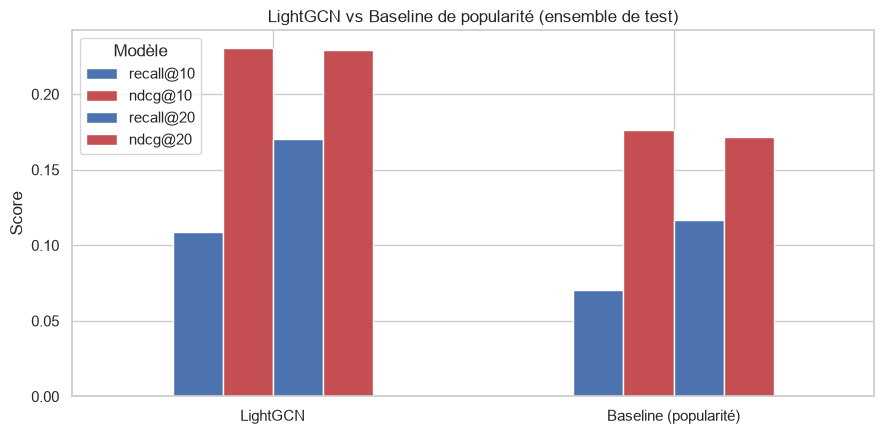

In [21]:
comparison_df.plot(kind="bar", figsize=(9, 4.5), color=["#4C72B0", "#C44E52"])
plt.title("LightGCN vs Baseline de popularité (ensemble de test)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Modèle")
plt.tight_layout()
plt.show()


## 12. Analyse des embeddings appris

Pour comprendre ce que le modèle a appris, nous projetons les embeddings d'articles en 2D avec
une **ACP (PCA)** et observons si des films de genres similaires se regroupent dans l'espace
latent - un signe que la propagation multicouche capture bien des signaux collaboratifs
cohérents avec le contenu, sans jamais avoir vu les genres pendant l'entraînement.

Nous illustrons également la notion de **similarité d'embeddings** en cherchant, pour quelques
films connus, leurs plus proches voisins dans l'espace appris par LightGCN.

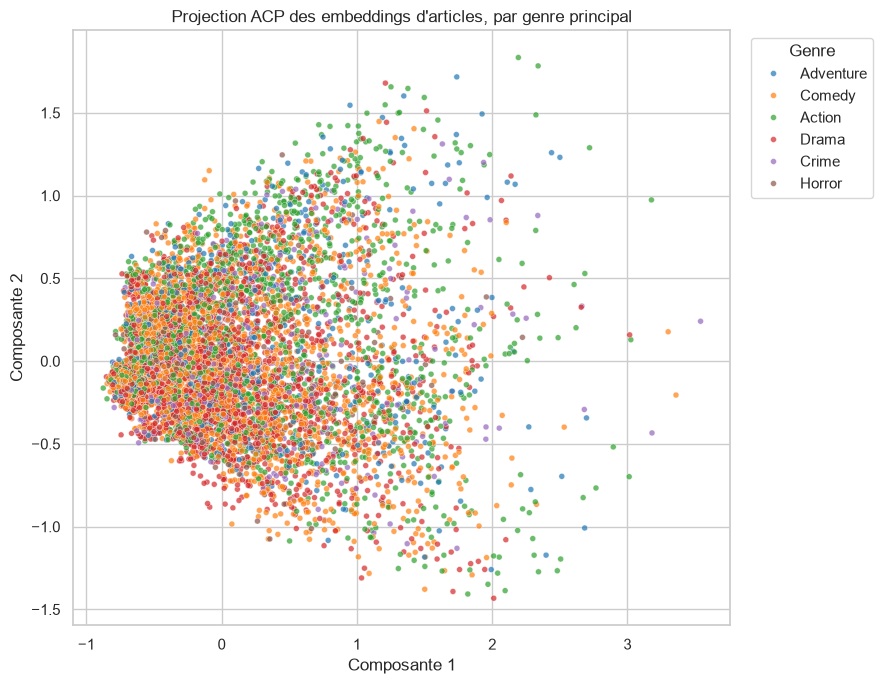

In [22]:
with torch.no_grad():
    final_users_emb, final_items_emb = final_model.propagate()
    final_users_emb = final_users_emb.cpu().numpy()
    final_items_emb = final_items_emb.cpu().numpy()

# Genre principal de chaque film (premier genre listé)
movies_indexed = movies.set_index("movieId")
item_main_genre = []
for idx in range(N_ITEMS):
    movie_id = idx2item[idx]
    genres = movies_indexed.loc[movie_id, "genres"]
    item_main_genre.append(genres.split("|")[0] if genres != "(no genres listed)" else "Inconnu")

# Sélection des genres les plus fréquents pour une visualisation lisible
top_genres = pd.Series(item_main_genre).value_counts().head(6).index.tolist()
mask = np.isin(item_main_genre, top_genres)

pca = PCA(n_components=2, random_state=SEED)
emb_2d = pca.fit_transform(final_items_emb[mask])

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=emb_2d[:, 0], y=emb_2d[:, 1],
    hue=np.array(item_main_genre)[mask], palette="tab10", s=18, alpha=0.7,
)
plt.title("Projection ACP des embeddings d'articles, par genre principal")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [23]:
def most_similar_movies(movie_title_substring, top_n=5):
    '''Retourne les films les plus proches (similarité cosinus) d'un film donné.'''
    matches = movies[movies['title'].str.contains(movie_title_substring, case=False, regex=False)]
    if matches.empty:
        print("Aucun film trouvé.")
        return
    movie_id = matches.iloc[0]['movieId']
    item_idx = item2idx[movie_id]

    emb = final_items_emb
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    normalized = emb / np.clip(norms, 1e-10, None)
    sims = normalized @ normalized[item_idx]

    top_indices = np.argsort(-sims)[1:top_n + 1]  # on exclut le film lui-même
    print(f"Films les plus similaires à « {matches.iloc[0]['title']} » :")
    for idx in top_indices:
        title = movies_indexed.loc[idx2item[idx], "title"]
        genres = movies_indexed.loc[idx2item[idx], "genres"]
        print(f"  - {title}  (similarité={sims[idx]:.3f}, genres={genres})")

most_similar_movies("Toy Story")
print()
most_similar_movies("Matrix")


Films les plus similaires à « Toy Story (1995) » :
  - Silence of the Lambs, The (1991)  (similarité=0.990, genres=Crime|Horror|Thriller)
  - Terminator 2: Judgment Day (1991)  (similarité=0.988, genres=Action|Sci-Fi)
  - Happy Gilmore (1996)  (similarité=0.987, genres=Comedy)
  - Braveheart (1995)  (similarité=0.987, genres=Action|Drama|War)
  - Pulp Fiction (1994)  (similarité=0.986, genres=Comedy|Crime|Drama|Thriller)

Films les plus similaires à « Matrix, The (1999) » :
  - Gladiator (2000)  (similarité=0.990, genres=Action|Adventure|Drama)
  - Minority Report (2002)  (similarité=0.989, genres=Action|Crime|Mystery|Sci-Fi|Thriller)
  - Snatch (2000)  (similarité=0.988, genres=Comedy|Crime|Thriller)
  - Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)  (similarité=0.987, genres=Action|Adventure)
  - Big Lebowski, The (1998)  (similarité=0.986, genres=Comedy|Crime)


## 13. Génération de recommandations Top-K

Pour quelques utilisateurs choisis, nous affichons les films qu'ils ont le plus aimés
(notes les plus élevées dans l'historique complet) ainsi que les **10 recommandations**
générées par LightGCN (films jamais notés par l'utilisateur).

In [24]:
@torch.no_grad()
def recommend_top_k(model, user_idx, k=10, exclude_dfs=(train_df, val_df, test_df)):
    '''Génère les K meilleures recommandations pour un utilisateur donné.'''
    users_emb, items_emb = model.propagate()
    scores = items_emb @ users_emb[user_idx]

    seen = set()
    for df in exclude_dfs:
        seen.update(df.loc[df['u'] == user_idx, 'i'].tolist())
    if seen:
        scores[list(seen)] = -np.inf

    top_items = torch.topk(scores, k=k).indices.cpu().numpy()
    return top_items


def show_user_profile_and_recommendations(user_idx, k=10):
    user_id = idx2user[user_idx]
    history = ratings[ratings['userId'] == user_id].merge(movies, on="movieId")
    top_liked = history.sort_values("rating", ascending=False).head(5)

    print(f"=== Utilisateur {user_id} ===")
    print("Films préférés (historique) :")
    for _, row in top_liked.iterrows():
        print(f"  - {row['title']}  (note={row['rating']}, genres={row['genres']})")

    recommended = recommend_top_k(final_model, user_idx, k=k, exclude_dfs=(train_df, val_df))
    print(f"\nTop-{k} recommandations LightGCN (films jamais notés) :")
    for idx in recommended:
        movie_id = idx2item[idx]
        title = movies_indexed.loc[movie_id, "title"]
        genres = movies_indexed.loc[movie_id, "genres"]
        print(f"  - {title}  (genres={genres})")
    print()


for sample_user_idx in [0, 5, 42]:
    show_user_profile_and_recommendations(sample_user_idx, k=10)


=== Utilisateur 1 ===
Films préférés (historique) :
  - Seven (a.k.a. Se7en) (1995)  (note=5.0, genres=Mystery|Thriller)
  - Usual Suspects, The (1995)  (note=5.0, genres=Crime|Mystery|Thriller)
  - Bottle Rocket (1996)  (note=5.0, genres=Adventure|Comedy|Crime|Romance)
  - Dumb & Dumber (Dumb and Dumber) (1994)  (note=5.0, genres=Adventure|Comedy)
  - Billy Madison (1995)  (note=5.0, genres=Comedy)

Top-10 recommandations LightGCN (films jamais notés) :
  - Shawshank Redemption, The (1994)  (genres=Crime|Drama)
  - Pulp Fiction (1994)  (genres=Comedy|Crime|Drama|Thriller)
  - Terminator 2: Judgment Day (1991)  (genres=Action|Sci-Fi)
  - Star Wars: Episode IV - A New Hope (1977)  (genres=Action|Adventure|Sci-Fi)
  - Apollo 13 (1995)  (genres=Adventure|Drama|IMAX)
  - Fugitive, The (1993)  (genres=Thriller)
  - True Lies (1994)  (genres=Action|Adventure|Comedy|Romance|Thriller)
  - Twelve Monkeys (a.k.a. 12 Monkeys) (1995)  (genres=Mystery|Sci-Fi|Thriller)
  - Aladdin (1992)  (genres=Ad


Top-10 recommandations LightGCN (films jamais notés) :
  - Batman (1989)  (genres=Action|Crime|Thriller)
  - Die Hard: With a Vengeance (1995)  (genres=Action|Crime|Thriller)
  - Broken Arrow (1996)  (genres=Action|Adventure|Thriller)
  - Twelve Monkeys (a.k.a. 12 Monkeys) (1995)  (genres=Mystery|Sci-Fi|Thriller)
  - Eraser (1996)  (genres=Action|Drama|Thriller)
  - Speed (1994)  (genres=Action|Romance|Thriller)
  - Quiz Show (1994)  (genres=Drama)
  - Mission: Impossible (1996)  (genres=Action|Adventure|Mystery|Thriller)
  - Addams Family Values (1993)  (genres=Children|Comedy|Fantasy)
  - Get Shorty (1995)  (genres=Comedy|Crime|Thriller)

=== Utilisateur 43 ===
Films préférés (historique) :
  - Toy Story (1995)  (note=5.0, genres=Adventure|Animation|Children|Comedy|Fantasy)
  - Grumpier Old Men (1995)  (note=5.0, genres=Comedy|Romance)
  - Father of the Bride Part II (1995)  (note=5.0, genres=Comedy)
  - Sabrina (1995)  (note=5.0, genres=Comedy|Romance)
  - Tom and Huck (1995)  (not


Top-10 recommandations LightGCN (films jamais notés) :
  - Silence of the Lambs, The (1991)  (genres=Crime|Horror|Thriller)
  - Pulp Fiction (1994)  (genres=Comedy|Crime|Drama|Thriller)
  - Clear and Present Danger (1994)  (genres=Action|Crime|Drama|Thriller)
  - Independence Day (a.k.a. ID4) (1996)  (genres=Action|Adventure|Sci-Fi|Thriller)
  - Stargate (1994)  (genres=Action|Adventure|Sci-Fi)
  - Star Trek: Generations (1994)  (genres=Adventure|Drama|Sci-Fi)
  - Twelve Monkeys (a.k.a. 12 Monkeys) (1995)  (genres=Mystery|Sci-Fi|Thriller)
  - Ace Ventura: Pet Detective (1994)  (genres=Comedy)
  - Interview with the Vampire: The Vampire Chronicles (1994)  (genres=Drama|Horror)
  - Forrest Gump (1994)  (genres=Comedy|Drama|Romance|War)



## 14. Export des artefacts pour le déploiement

Le backend Flask n'a pas besoin de réentraîner le modèle ni de manipuler le dataset complet : il
lui suffit des **embeddings finaux** (utilisateurs et articles) et des **tables de
correspondance** d'identifiants pour calculer, à la volée, le produit scalaire
$\hat{y}_{ui} = e_u^\top e_i$ et retourner le Top-K.

Nous exportons :
- `user_embeddings.npy` et `item_embeddings.npy` : embeddings finaux (post-propagation),
- `mappings.json` : correspondances `userId <-> index` et `movieId <-> index`,
- `movies_metadata.csv` : métadonnées légères des films (id, titre, genres, identifiant TMDb),
- `model_state.pt` : poids du modèle PyTorch (pour ré-entraînement ou inspection ultérieure),
- `eval_metrics.json` : métriques finales et hyperparamètres retenus.

In [25]:
# Embeddings finaux (utilisateurs et articles)
np.save(os.path.join(MODELS_DIR, "user_embeddings.npy"), final_users_emb.astype(np.float32))
np.save(os.path.join(MODELS_DIR, "item_embeddings.npy"), final_items_emb.astype(np.float32))

# Tables de correspondance d'identifiants
mappings = {
    "user2idx": {str(k): v for k, v in user2idx.items()},
    "item2idx": {str(k): v for k, v in item2idx.items()},
    "idx2user": {str(k): v for k, v in idx2user.items()},
    "idx2item": {str(k): v for k, v in idx2item.items()},
}
with open(os.path.join(MODELS_DIR, "mappings.json"), "w", encoding="utf-8") as f:
    json.dump(mappings, f, ensure_ascii=False)

# Métadonnées légères des films (id, titre, genres, identifiant TMDb pour les affiches)
movies_export = movies.merge(links[['movieId', 'tmdbId', 'imdbId']], on="movieId", how="left")
movies_export.to_csv(os.path.join(MODELS_DIR, "movies_metadata.csv"), index=False)

# Poids du modèle PyTorch
torch.save({
    "state_dict": final_model.state_dict(),
    "embedding_dim": BEST_EMBEDDING_DIM,
    "n_layers": BEST_N_LAYERS,
    "n_users": N_USERS,
    "n_items": N_ITEMS,
}, os.path.join(MODELS_DIR, "model_state.pt"))

# Métriques et hyperparamètres finaux
export_info = {
    "hyperparameters": {
        "embedding_dim": BEST_EMBEDDING_DIM,
        "n_layers": BEST_N_LAYERS,
        "learning_rate": FIXED_LR,
        "l2_reg": FIXED_L2,
        "batch_size": 4096,
    },
    "test_metrics": test_metrics,
    "baseline_metrics": baseline_results,
    "n_users": N_USERS,
    "n_items": N_ITEMS,
}
with open(os.path.join(MODELS_DIR, "eval_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(export_info, f, ensure_ascii=False, indent=2)

print("Artefacts exportés dans le dossier 'models/' :")
for fname in sorted(os.listdir(MODELS_DIR)):
    path = os.path.join(MODELS_DIR, fname)
    print(f"  - {fname} ({os.path.getsize(path)/1024:.1f} Ko)")


Artefacts exportés dans le dossier 'models/' :
  - eval_metrics.json (0.5 Ko)
  - item_embeddings.npy (2431.1 Ko)
  - mappings.json (287.7 Ko)
  - model_state.pt (2585.3 Ko)
  - movies_metadata.csv (623.0 Ko)
  - user_embeddings.npy (152.6 Ko)


## 15. Conclusion

Dans ce notebook, nous avons :

1. Analysé le jeu de données **MovieLens ml-latest-small** (utilisateurs, films, notes, genres).
2. Construit un **graphe biparti utilisateur-article** normalisé pour le filtrage collaboratif.
3. Implémenté **LightGCN** en PyTorch, avec propagation d'embeddings multicouches et combinaison
   par moyenne des représentations de chaque couche.
4. Entraîné le modèle avec la perte **BPR** et un échantillonnage négatif aléatoire.
5. Sélectionné les meilleurs hyperparamètres (`embedding_dim`, `n_layers`) par validation.
6. Évalué le modèle final avec **Recall@K** et **NDCG@K**, en le comparant favorablement à une
   baseline de popularité.
7. Analysé les embeddings appris (regroupement par genre, similarité entre films).
8. Exporté tous les artefacts nécessaires au **backend Flask** (dossier `models/`), qui calcule
   les recommandations en production à partir de ces embeddings pré-entraînés, sans avoir besoin
   du dataset complet.

La suite du projet (backend Flask + frontend Next.js) consomme directement les artefacts du
dossier `models/` pour proposer des recommandations personnalisées en temps réel.